In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

from ts_toolkit.io import clean_timeseries
from ts_toolkit.calendar import add_hour_sin_cos
from ts_toolkit.viz import plot_history_forecast
from ts_toolkit.split import three_way_split
from src.models.log_transform_model import DetrendingLogRecursiveModel
from ts_toolkit.metrics import daily_mae
from ts_toolkit.metrics import global_metrics
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import os
import datetime

In [2]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 10:50:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="common_cad_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


                     common_cad
ts                             
2024-11-25 18:01:00  570.036987
2024-11-25 18:01:15  570.036987
2024-11-25 18:01:30  570.036987
2024-11-25 18:01:45  570.036987
2024-11-25 18:02:00  984.271301
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90437 entries, 2024-11-25 18:01:00 to 2024-12-11 10:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   common_cad  90437 non-null  float64
dtypes: float64(1)
memory usage: 1.4 MB
None
         common_cad
count  90437.000000
mean     423.157471
std      200.322570
min      205.757349
25%      314.537964
50%      389.539380
75%      483.270654
max     8093.401355
common_cad    0
dtype: int64


In [3]:
df = clean_timeseries(df, 'common_cad')   # вместо блока 0‑3


In [4]:
import logging

model_name = "detrending_log_transform_model_v1_cv_common_cad"

os.makedirs(f"plots/{model_name}", exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"plots/{model_name}/results.log"),
        logging.StreamHandler()
    ]
)


In [5]:
logging.info(df.describe())

2025-06-16 15:01:02,016 - INFO -          common_cad
count  90437.000000
mean     423.157471
std      200.322570
min      205.757349
25%      314.537964
50%      389.539380
75%      483.270654
max     8093.401355


In [6]:
# Разделяем данные
df_train, df_val, df_hold = three_way_split(df, train_ratio=0.8, val_ratio=0.19)

# ── Создание и обучение модели ─────────────────────────────────
model = DetrendingLogRecursiveModel(
    horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
    lags=[1, 2, 4, 96, 192, 5760],
    roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
)
# model = DetrendingLogRecursiveModel(
#     horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
#     lags=[96, 192, 5760],
#     roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
# )

# Обучаем модель. fit больше не возвращает датафреймы.
logging.info("Начинаю обучение модели...")
model.fit(
    train_df=df_train, 
    target_col='common_cad',
    val_df=df_val
    # feature_cols больше не нужны, модель сама создает календарные признаки
)
logging.info("Модель успешно обучена!")
model.save(model_name) 

2025-06-16 14:43:47,726 - INFO - Начинаю обучение модели...


2025-06-16 14:44:29,628 - INFO - Модель успешно обучена!


Model saved to detrending_log_transform_model_v1_cv_common_cad


In [7]:
model

In [8]:
# ── Прогноз на будущее (hold-out) ──────────────────────────
# Для предсказания нам нужна история, достаточная для создания самых "длинных" признаков
history_need = max(model.lags + model.roll_windows)

# Используем только доступную историю (train + val)
# .tail() не нужен, так как _prepare_features сам разберется
df_context = pd.concat([df_train, df_val])

# 🎯 НОВЫЙ МЕТОД ПРОГНОЗА: один вызов возвращает весь горизонт
logging.info("Делаю прогноз...")
y_pred_series = model.predict(df_hist=df_context)
logging.info("Прогноз готов!")

2025-06-16 14:44:29,786 - INFO - Делаю прогноз...
2025-06-16 14:48:33,712 - INFO - Прогноз готов!


In [6]:
# Разделяем данные: сначала отделяем hold-out, а на остальном будем делать кросс-валидацию
hold_out_size = int(len(df) * 0.01) # Например, 1% данных под hold-out. Можешь поменять.
df_train_val = df.iloc[:-hold_out_size]
df_hold = df.iloc[-hold_out_size:]

logging.info(f"Размер полного датасета: {len(df)}")
logging.info(f"Размер для обучения и CV: {len(df_train_val)}")
logging.info(f"Размер для hold-out теста: {len(df_hold)}")

2025-06-16 15:01:03,593 - INFO - Размер полного датасета: 90437
2025-06-16 15:01:03,595 - INFO - Размер для обучения и CV: 89533
2025-06-16 15:01:03,597 - INFO - Размер для hold-out теста: 904


2025-06-16 15:01:03,855 - INFO - Запускаю кросс-валидацию на 5 фолдах...
2025-06-16 15:01:03,860 - INFO - 
--- Фолд 1/5 ---
2025-06-16 15:01:03,865 - INFO - Размер train фолда 1: 85033
2025-06-16 15:01:03,868 - INFO - Размер val фолда 1: 900
2025-06-16 15:01:03,870 - INFO - Период фолда 1: 2024-11-25 18:01:00 - 2024-12-10 12:19:00
2025-06-16 15:01:03,872 - INFO - Начинаю обучение на фолде...
2025-06-16 15:01:40,936 - INFO - Обучение на фолде завершено.
2025-06-16 15:05:43,718 - INFO - Метрики на фолде 1: MAE=74.5, RMSE=87.9, MAPE=19.87%
2025-06-16 15:05:45,914 - INFO - 
--- Фолд 2/5 ---
2025-06-16 15:05:45,917 - INFO - Размер train фолда 2: 85933
2025-06-16 15:05:45,918 - INFO - Размер val фолда 2: 900
2025-06-16 15:05:45,919 - INFO - Период фолда 2: 2024-11-25 18:01:00 - 2024-12-10 16:04:00
2025-06-16 15:05:45,926 - INFO - Начинаю обучение на фолде...
2025-06-16 15:05:59,684 - INFO - Обучение на фолде завершено.
2025-06-16 15:09:03,700 - INFO - Метрики на фолде 2: MAE=77.0, RMSE=98.2,

Model saved to detrending_log_transform_model_v1_cv_common_cad


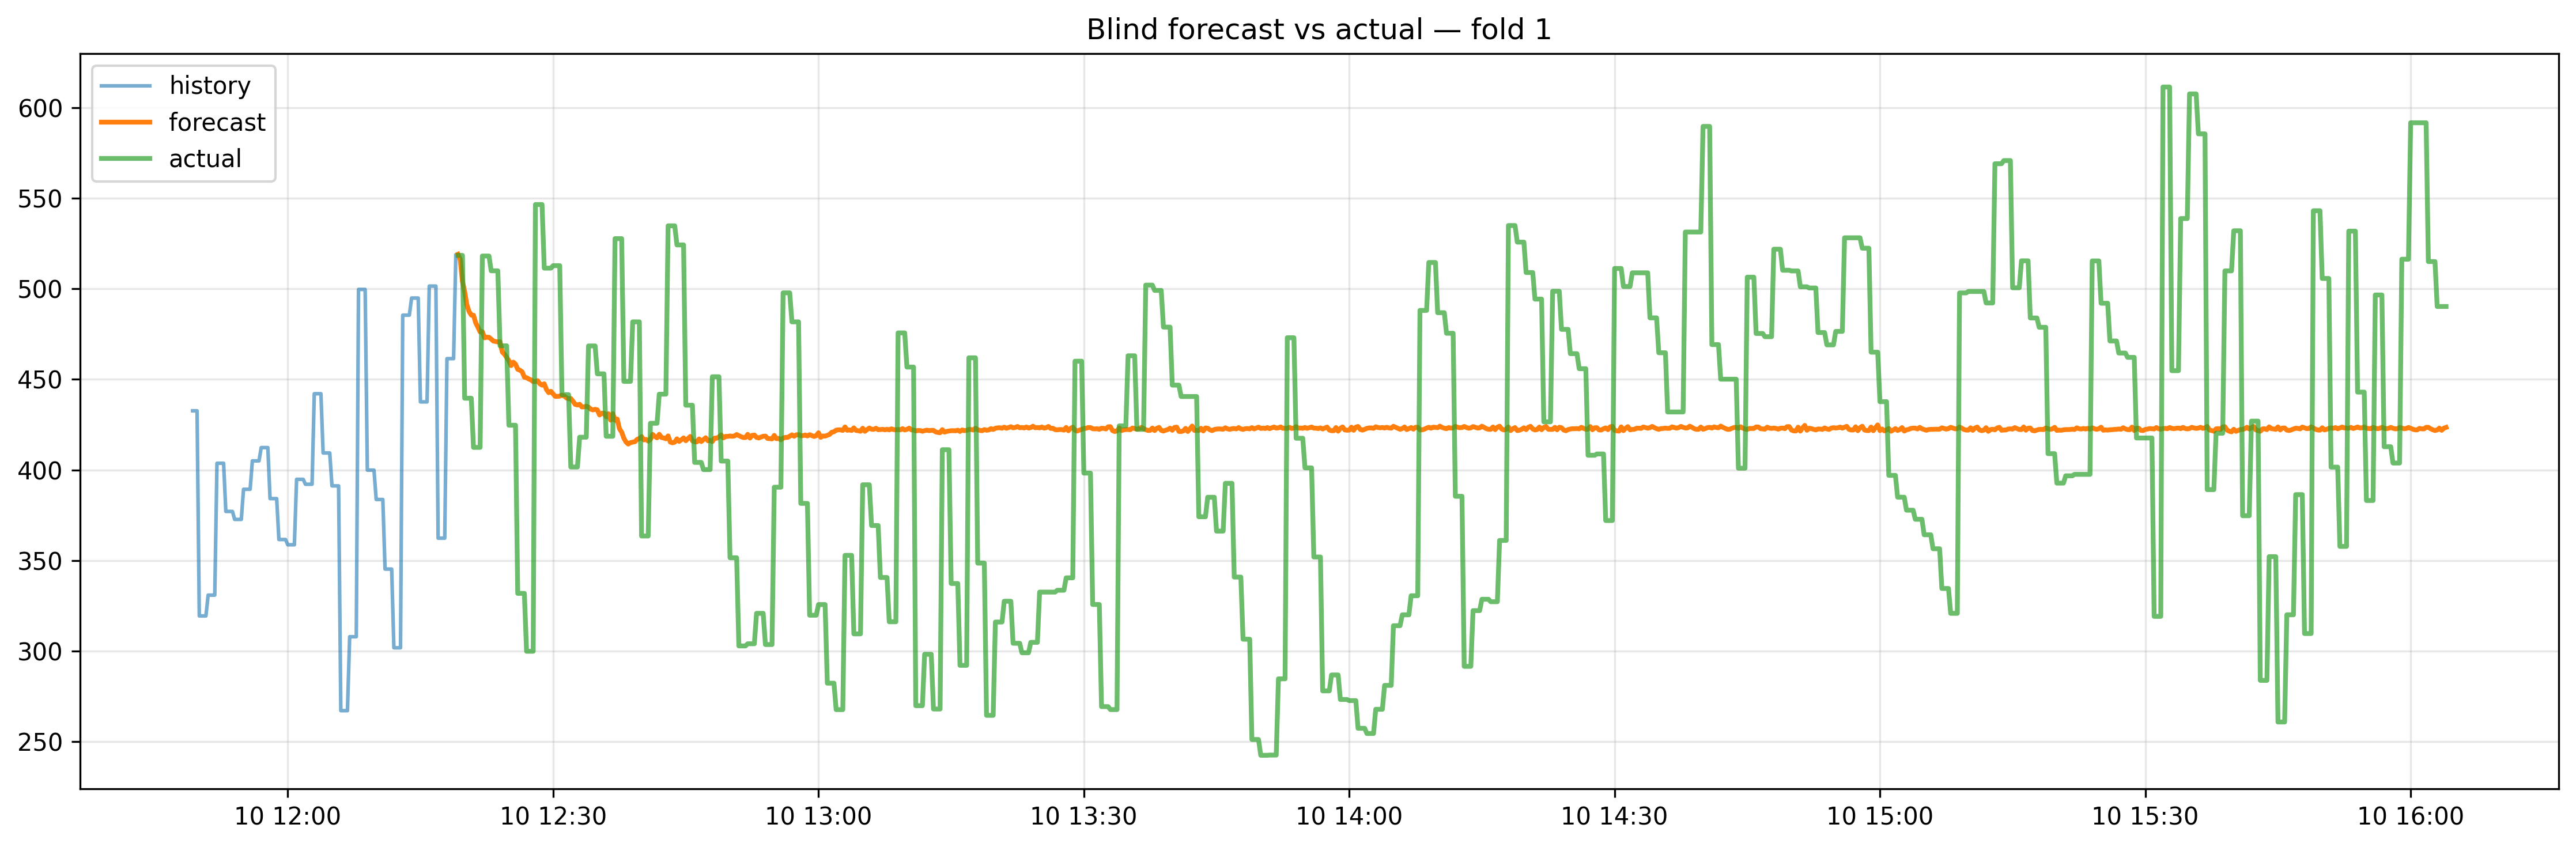

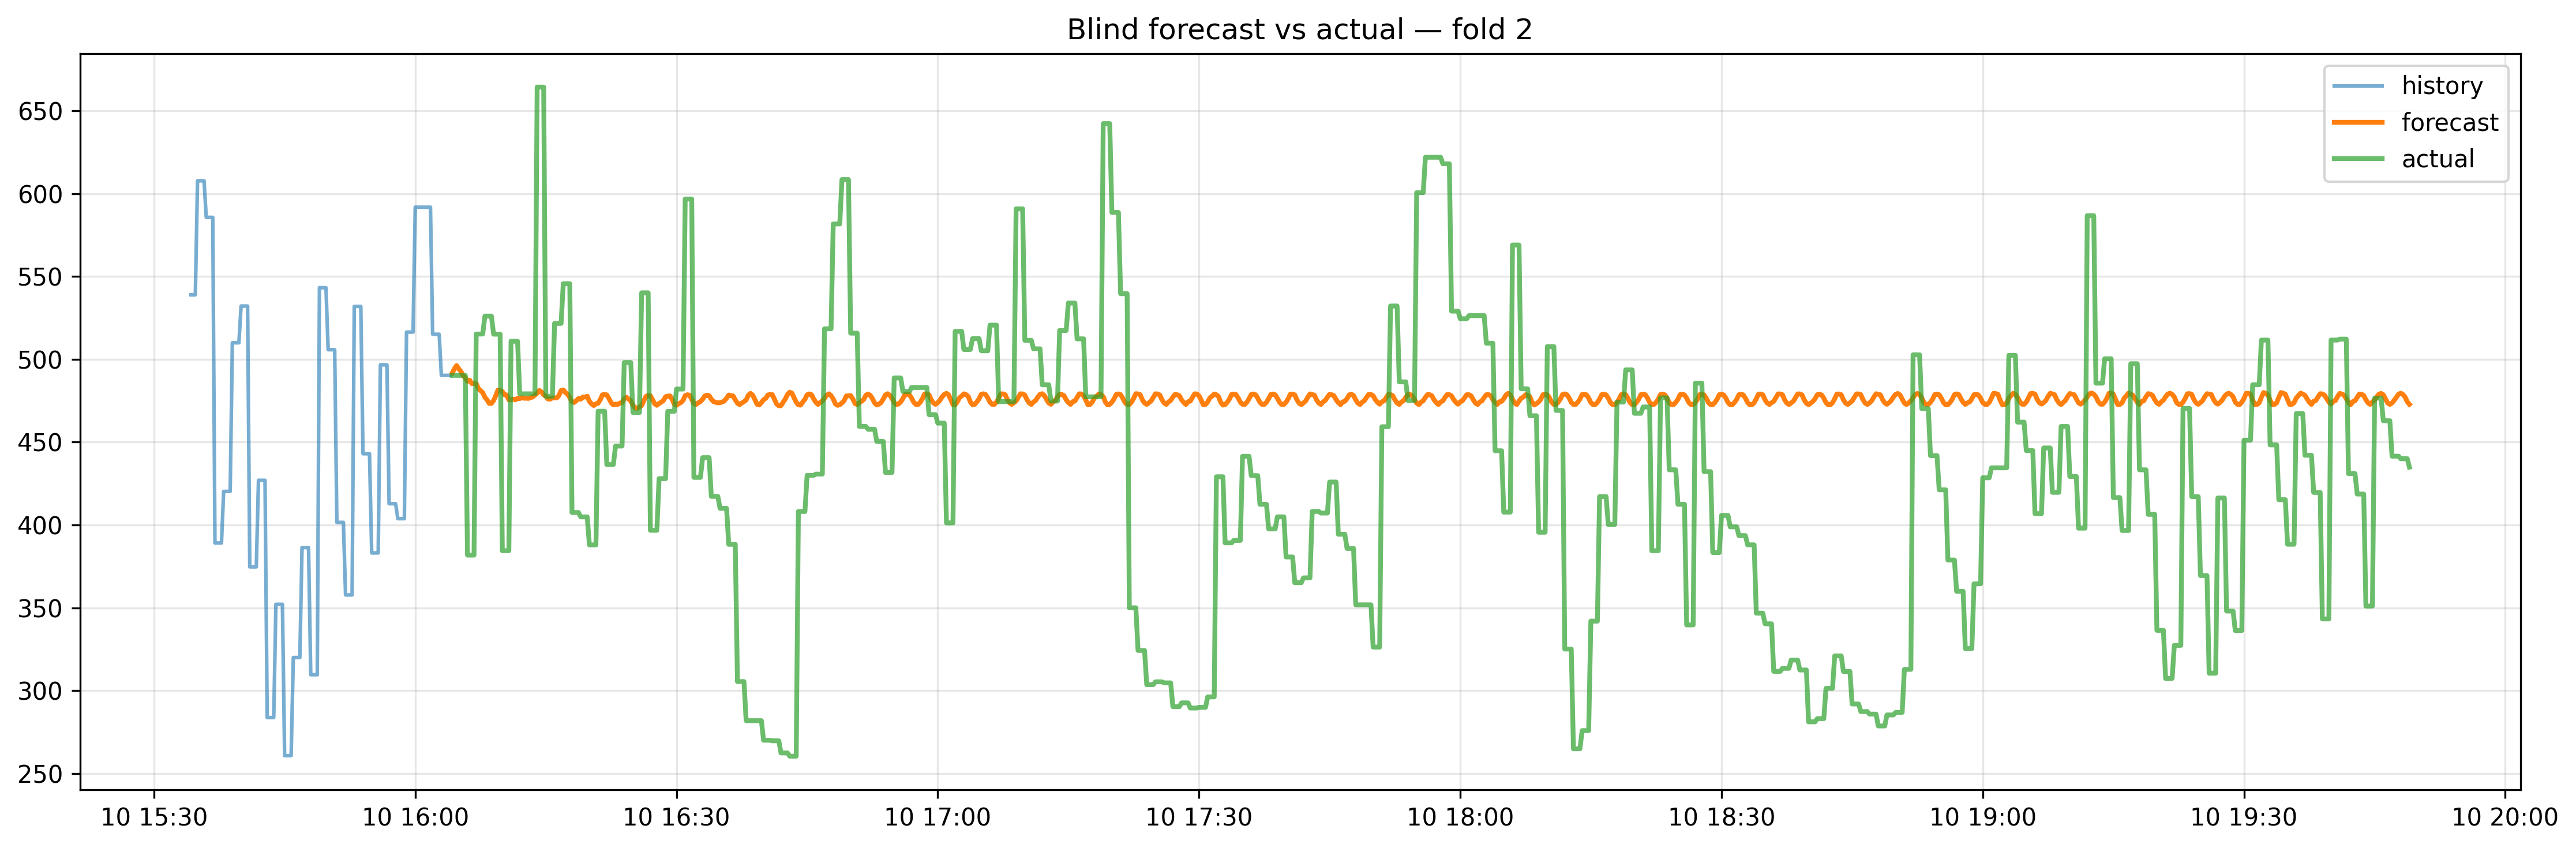

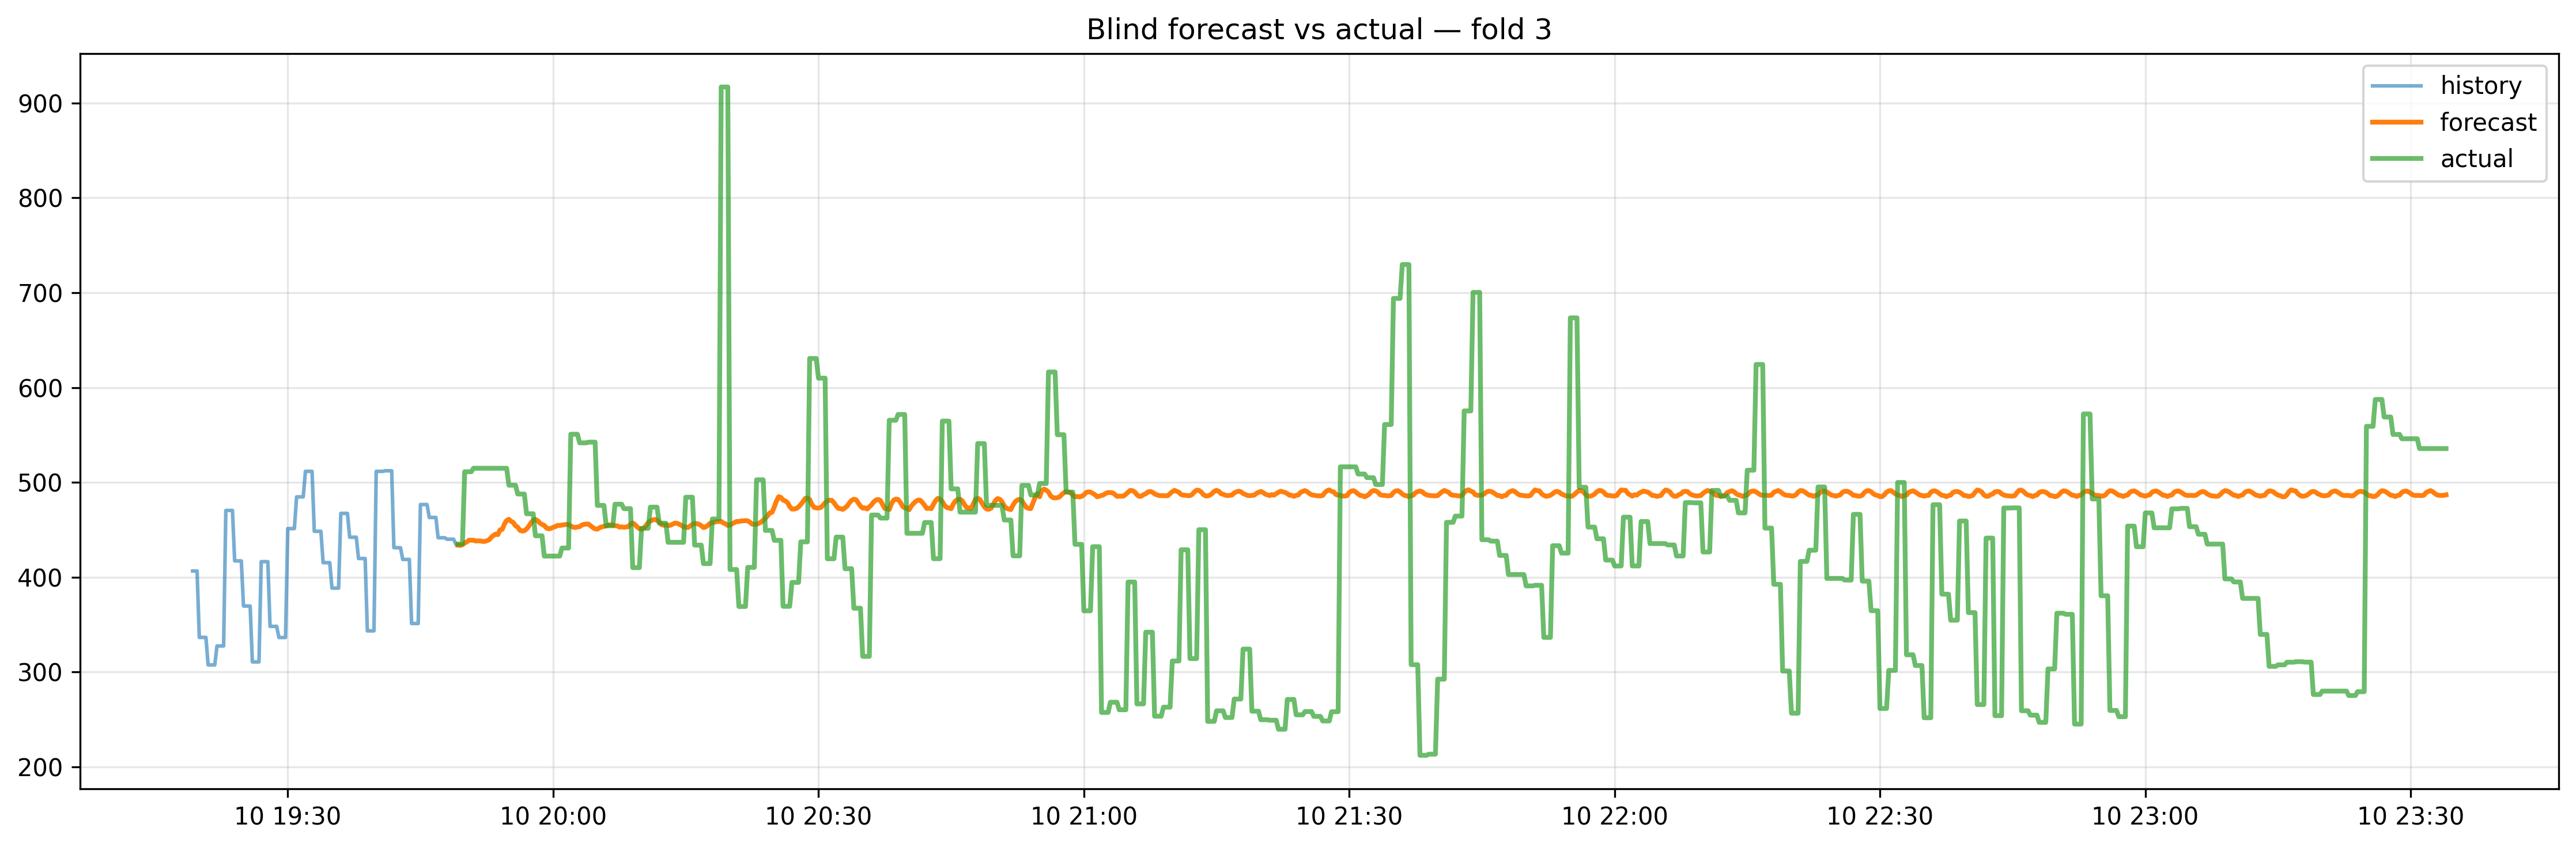

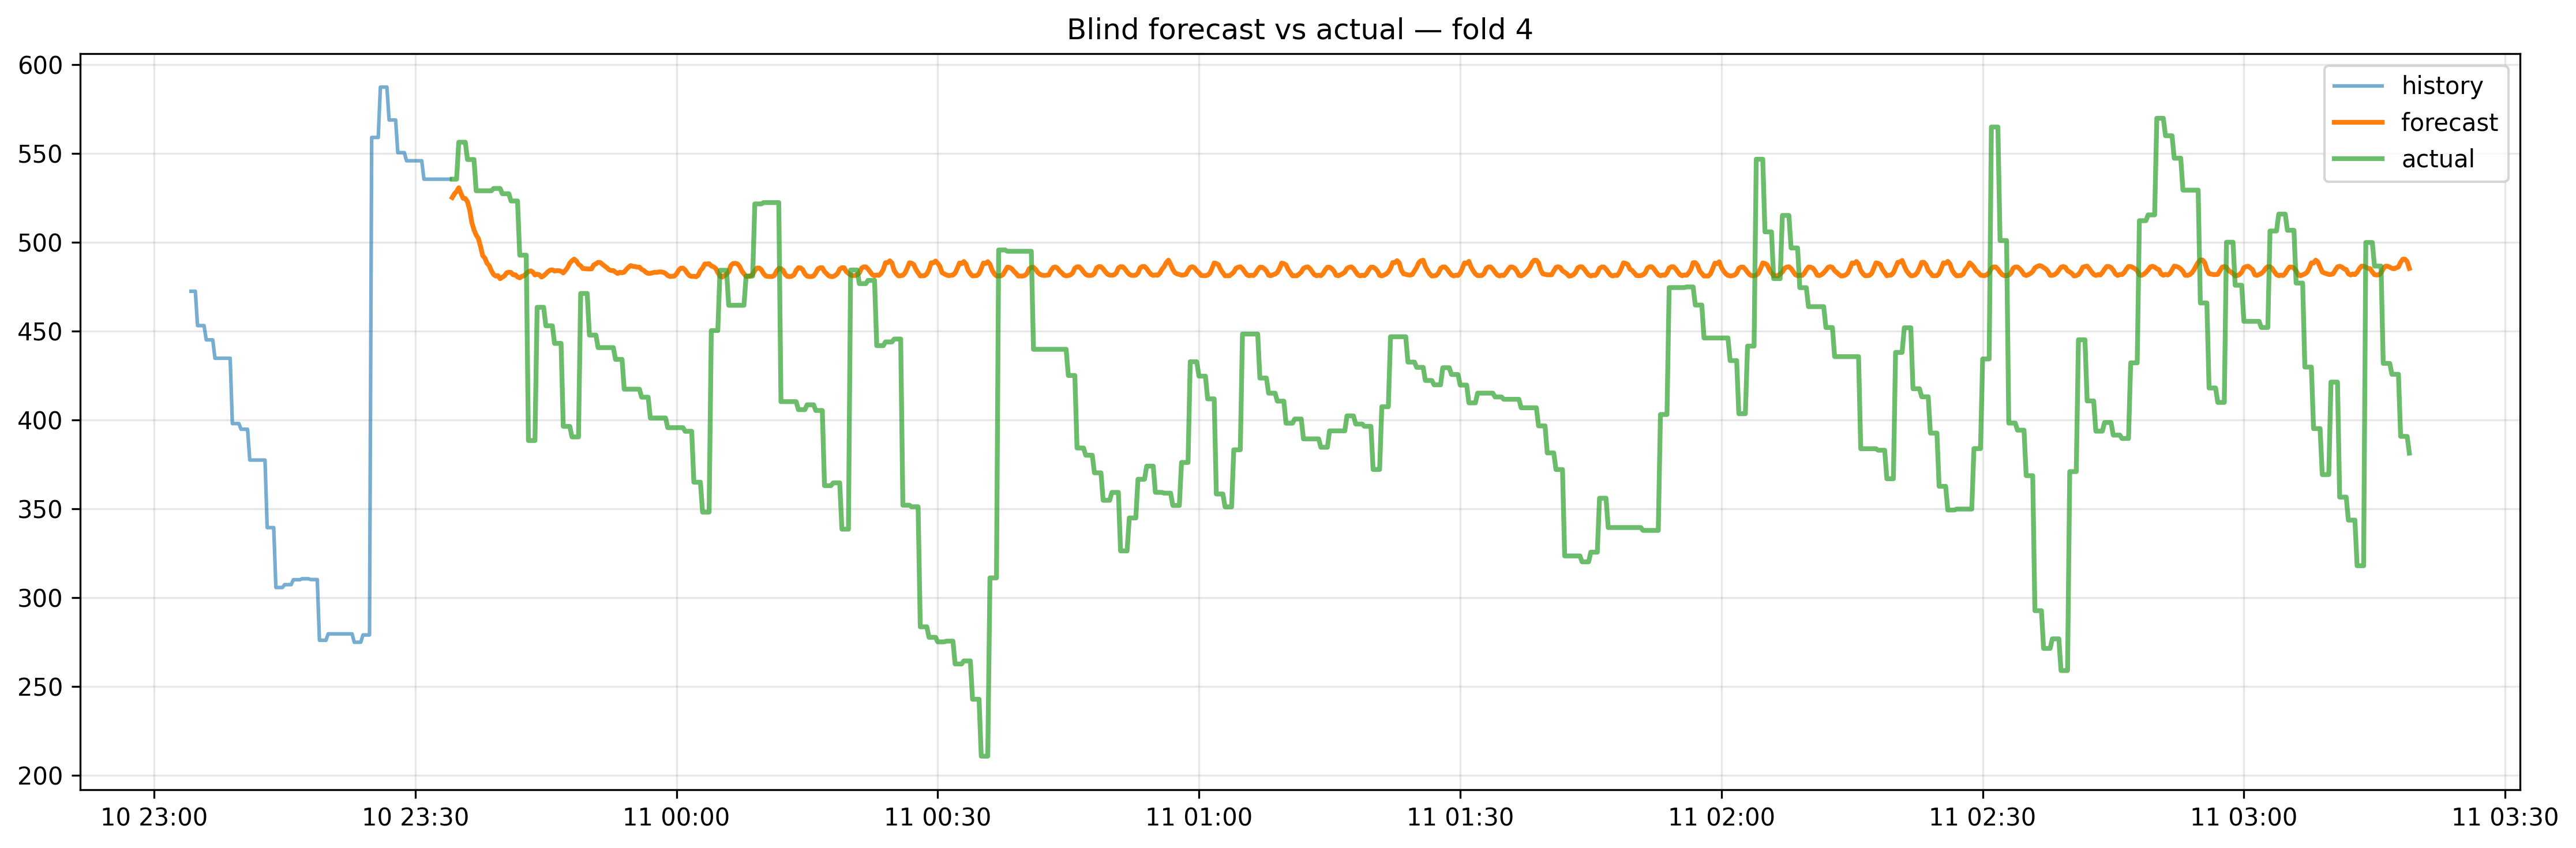

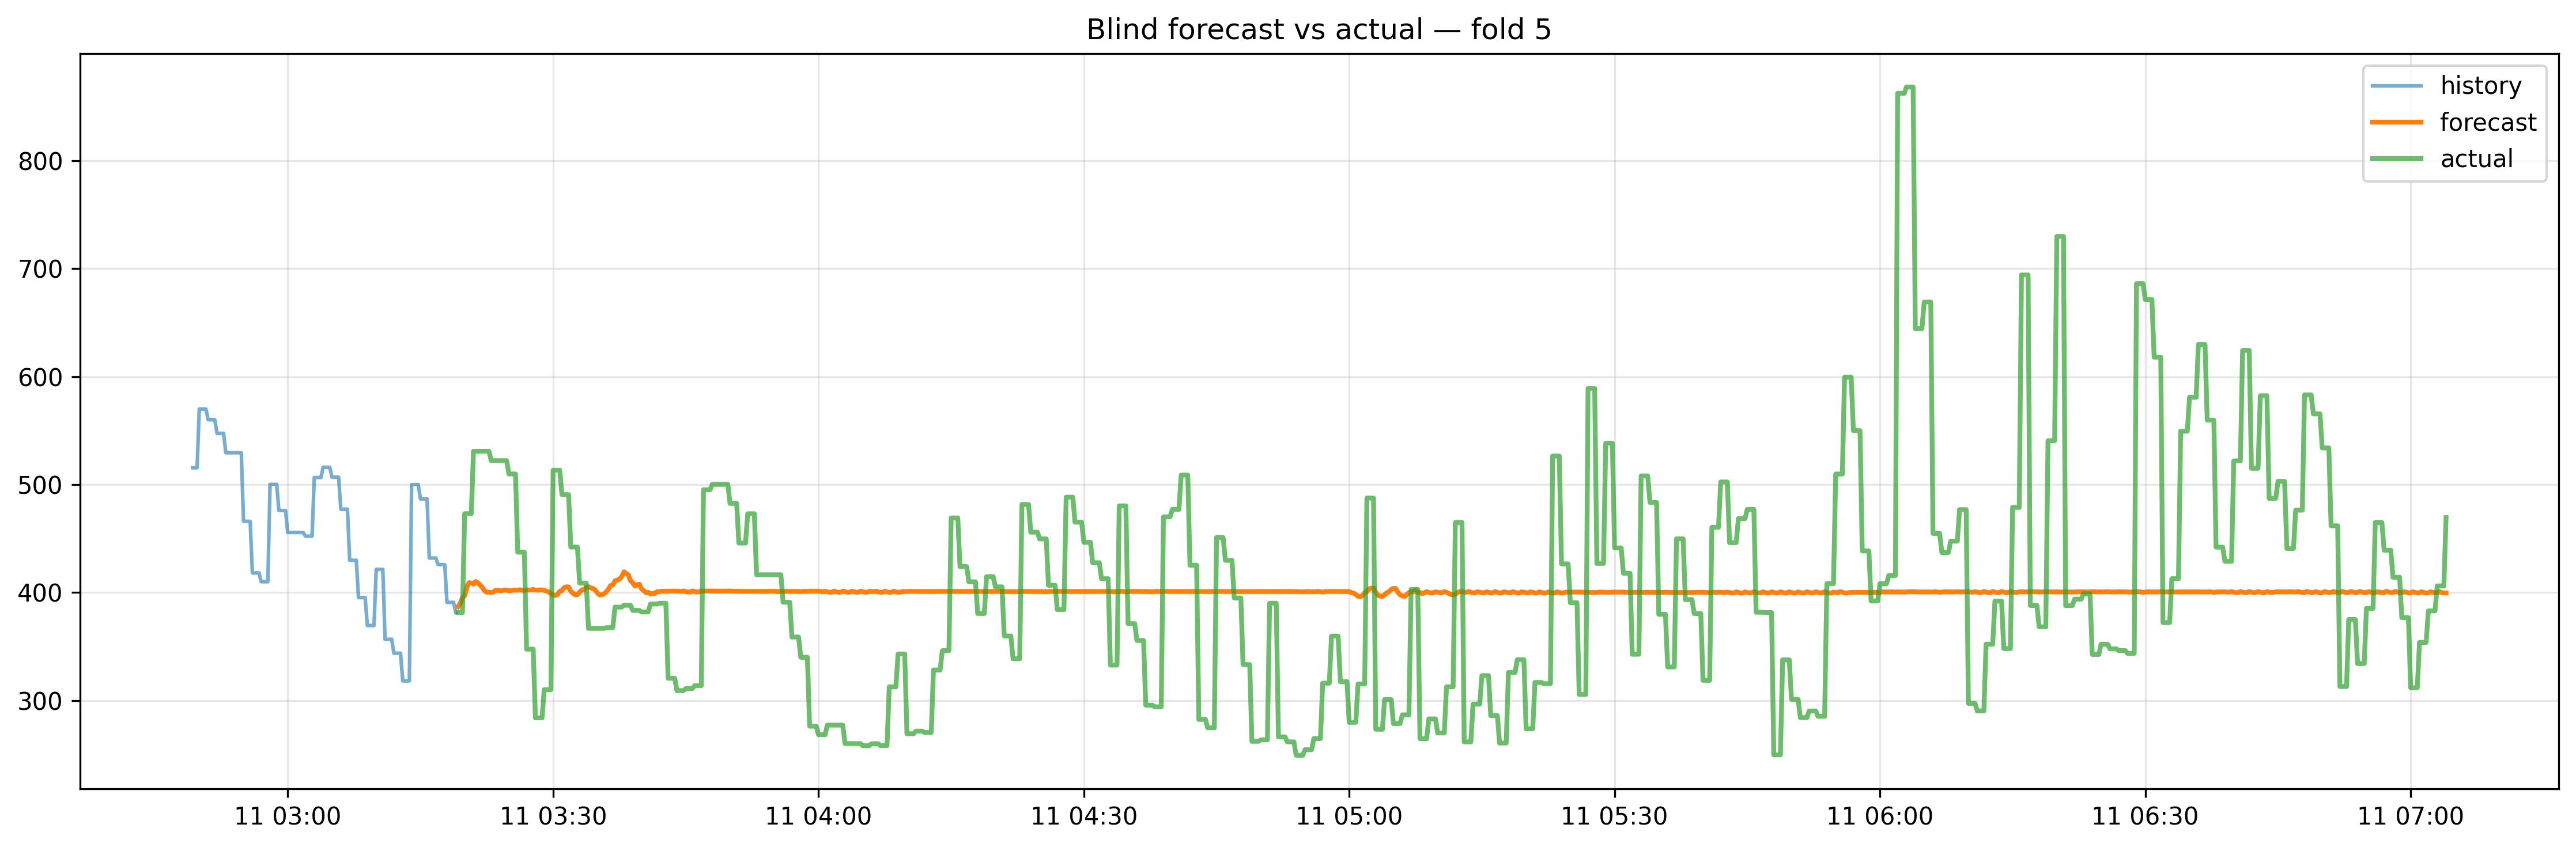

In [7]:
# ── Кросс-валидация с TimeSeriesSplit ─────────────────────────────────
n_splits = 5 # Количество фолдов для кросс-валидации
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=900)

metrics_list = []
logging.info(f"Запускаю кросс-валидацию на {n_splits} фолдах...")

for i, (train_index, val_index) in enumerate(tscv.split(df_train_val)):
    logging.info(f"\n--- Фолд {i+1}/{n_splits} ---")
    df_train_fold = df_train_val.iloc[train_index]
    df_val_fold = df_train_val.iloc[val_index]
    logging.info(f"Размер train фолда {i+1}: {len(df_train_fold)}")
    logging.info(f"Размер val фолда {i+1}: {len(df_val_fold)}")
    logging.info(f"Период фолда {i+1}: {df_train_fold.index[0]} - {df_train_fold.index[-1]}")

    # Модель для фолда
    model_fold = DetrendingLogRecursiveModel(
        horizon=len(df_val_fold), # Горизонт равен размеру валидационного сета
    #     lags=[96, 192, 5760],
    #     roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
    # )
        lags=[1, 2, 4, 96, 192, 5760],
        roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
    )
    
    logging.info("Начинаю обучение на фолде...")
    model_fold.fit(
        train_df=df_train_fold, 
        target_col='common_cad',
        val_df=df_val_fold
    )
    logging.info("Обучение на фолде завершено.")

    # Прогноз на валидационной части фолда
    y_pred_fold = model_fold.predict(df_hist=df_train_fold)
    y_true_fold = df_val_fold['common_cad'].reindex(y_pred_fold.index).dropna()
    
    # Выравниваем y_pred_fold по индексам y_true_fold, чтобы избежать ошибок в метриках
    y_pred_fold = y_pred_fold.reindex(y_true_fold.index).dropna()
    
    if len(y_true_fold) > 0 and len(y_pred_fold) > 0:
        fold_metrics = global_metrics(y_true_fold, y_pred_fold)
        metrics_list.append(fold_metrics)
        logging.info(f"Метрики на фолде {i+1}: MAE={fold_metrics['MAE']:.1f}, RMSE={fold_metrics['RMSE']:.1f}, MAPE={fold_metrics['MAPE']:.2f}%")
        # ── график: история 3 сут + прогноз vs факт ──
        # hist_start = pred_idx[0] - pd.Timedelta(hours=1)
        pred_idx = y_pred_fold.index
        hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
        plot_history_forecast(
            history  = df_train_fold.loc[hist_start:pred_idx[0], 'common_cad'],
            forecast = pd.Series(y_pred_fold, index=pred_idx),
            actual   = y_true_fold,
            title    = f'Blind forecast vs actual — fold {i+1}',
            filename = f'plots/{model_name}/cv_fold_{i+1}_forecast_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
        )
    else:
        logging.info(f"На фолде {i+1} не получилось посчитать метрики (нет пересечения данных).")


# Усредненные метрики по кросс-валидации
if metrics_list:
    avg_metrics = {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]}
    logging.info("\n--- Результаты кросс-валидации (средние) ---")
    logging.info(f"CV Avg • MAE={avg_metrics['MAE']:.1f}  RMSE={avg_metrics['RMSE']:.1f}  MAPE={avg_metrics['MAPE']:.2f}%")
else:
    logging.info("\nНе удалось собрать метрики ни на одном из фолдов.")


# ── Обучение финальной модели на всех данных (train+val) ───────────────
logging.info("\nНачинаю обучение финальной модели на всех данных train+val...")
final_model = DetrendingLogRecursiveModel(
    horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
    # lags=[96, 192, 5760],
    # roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
    lags=[1, 2, 4, 96, 192, 5760],
    roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
)

# Обучаем модель. val_df не передаем, т.к. используем все данные для обучения
final_model.fit(
    train_df=df_train_val, 
    target_col='common_cad'
)
logging.info("Финальная модель успешно обучена!")
final_model.save(model_name)

In [8]:
# ── Прогноз на будущее (hold-out) ──────────────────────────
logging.info("\nДелаю прогноз на hold-out сете...")

# Для предсказания используем всю историю до hold-out (df_train_val)
# Модель сама возьмет хвост нужной длины
y_pred_series = final_model.predict(df_hist=df_train_val)

logging.info("Прогноз готов!")

2025-06-16 15:27:27,049 - INFO - 
Делаю прогноз на hold-out сете...
2025-06-16 15:29:36,242 - INFO - Прогноз готов!


In [9]:
# Подготавливаем данные для сравнения
pred_idx = y_pred_series.index
y_true = df_hold['common_cad'].reindex(y_pred_series.index).dropna()
y_pred = y_pred_series.reindex(y_true.index).dropna() # Убедимся, что все выровнено

logging.info(f"Длина прогноза: {len(y_pred)}, Длина реальных данных: {len(y_true)}")

2025-06-16 15:29:36,364 - INFO - Длина прогноза: 904, Длина реальных данных: 904


2025-06-16 15:29:36,505 - INFO - Blind ~4h test • MAE=96.6  RMSE=131.5  MAPE=24.70%  on 904 valid points


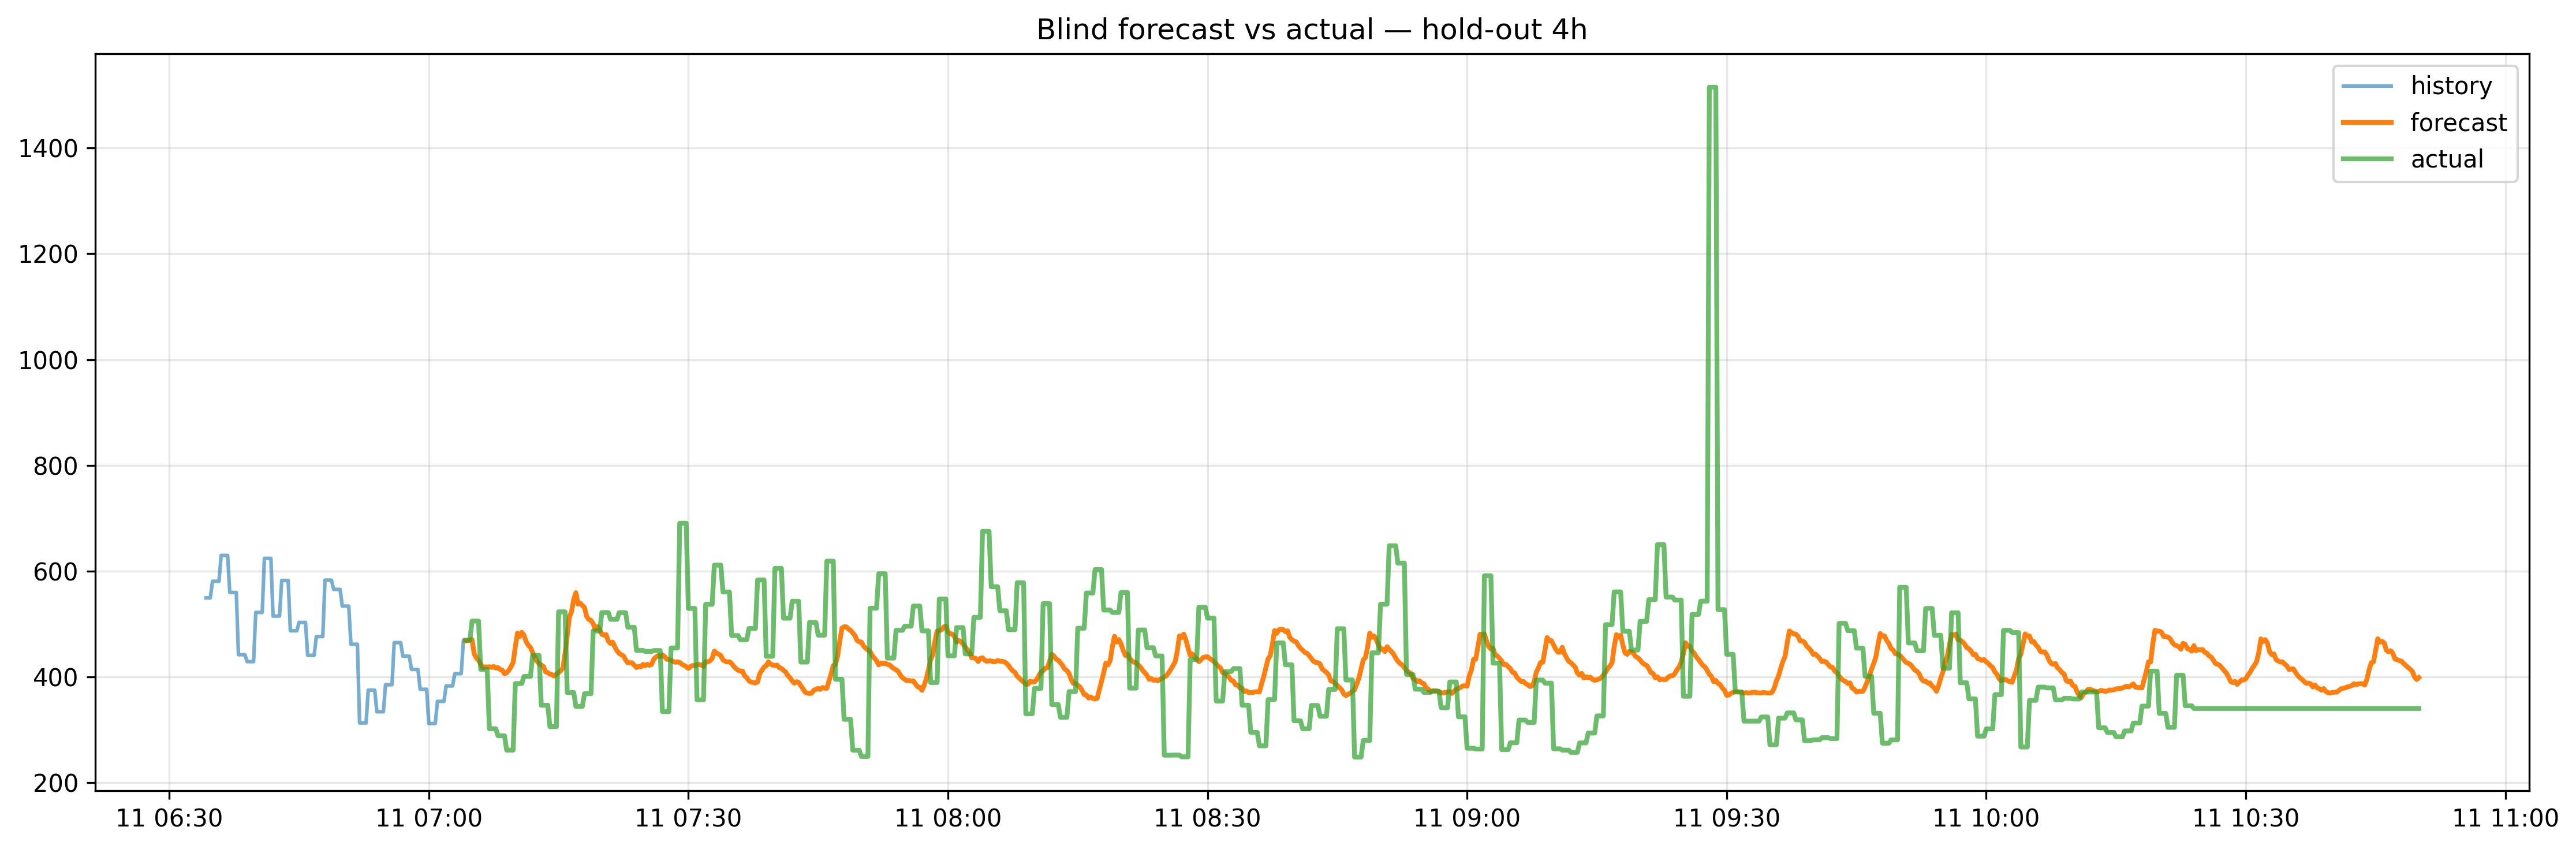

In [ ]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, y_pred)
logging.info(f"Blind ~4h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad'],
    forecast = pd.Series(y_pred, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 4h',
    filename = f'plots/{model_name}/final_hold_out_forecast_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.png'
)

<Axes: >

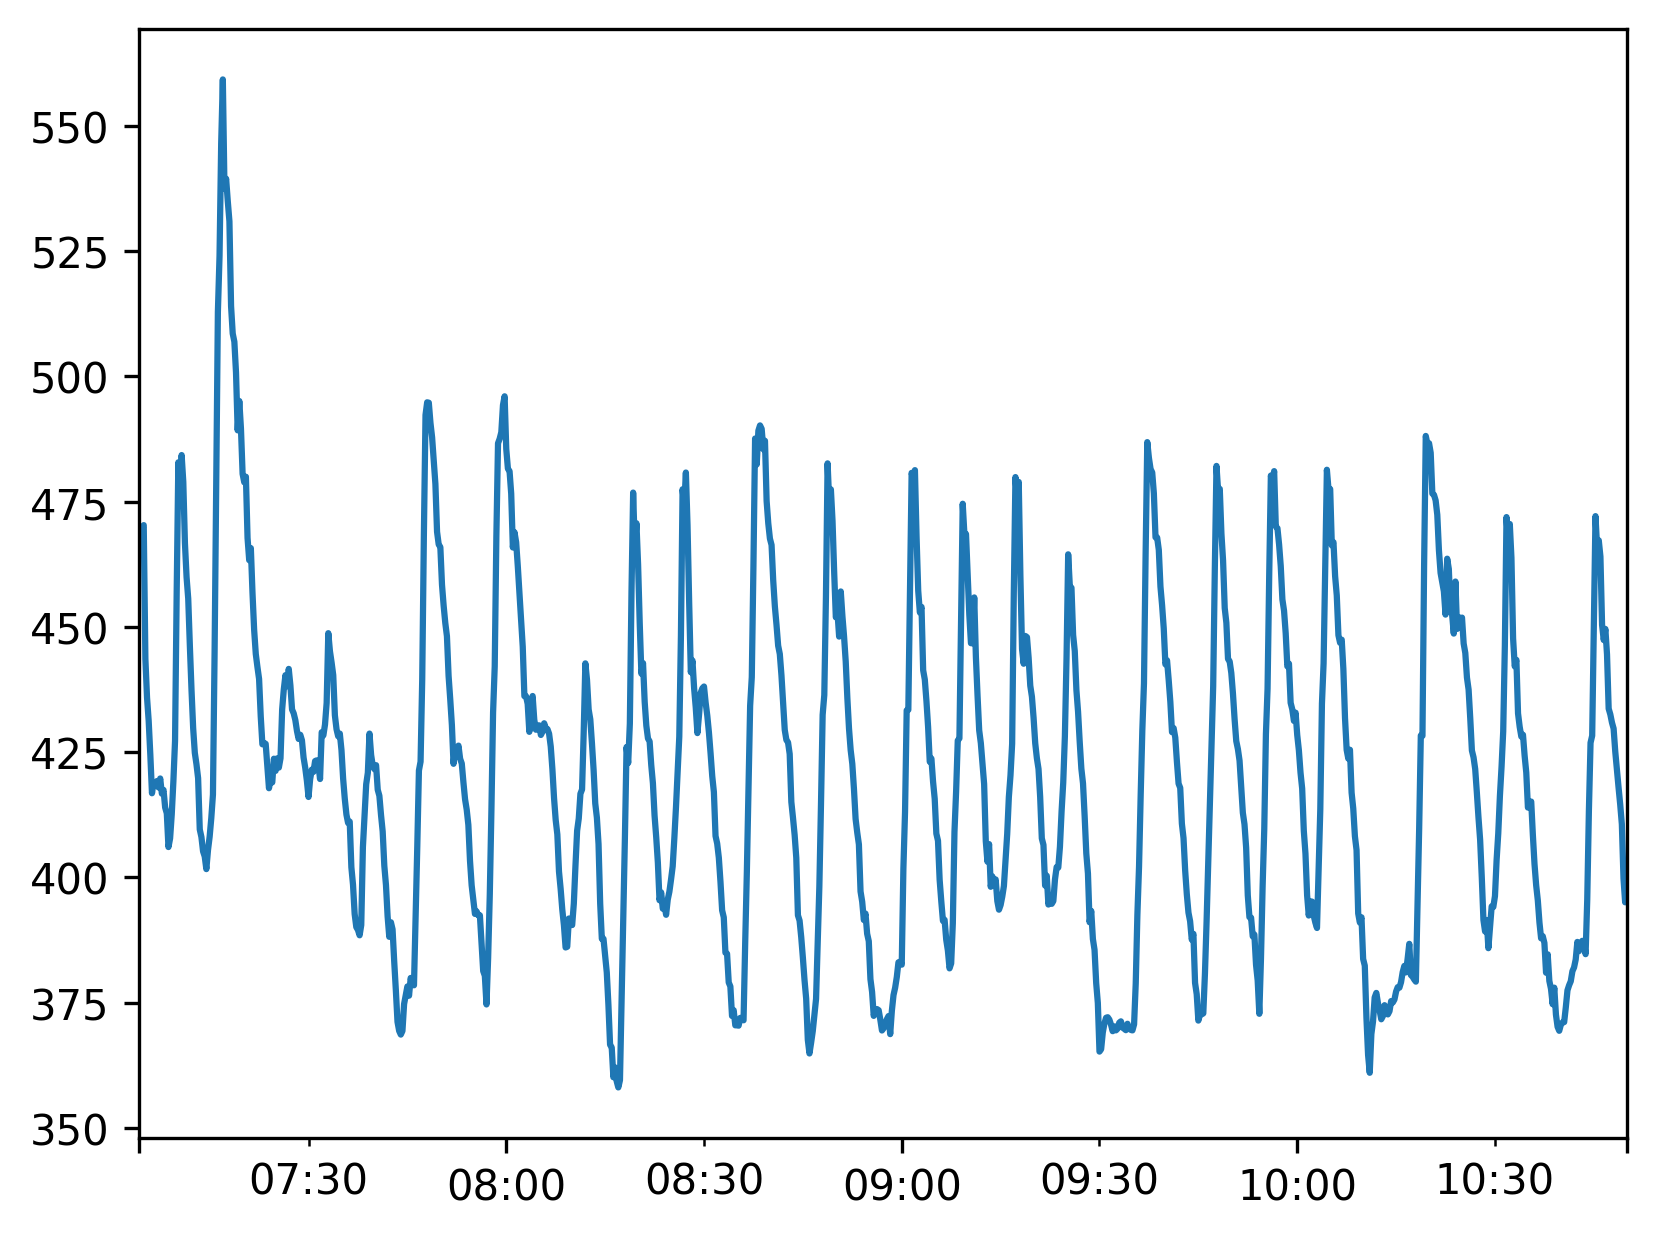

In [ ]:
pd.Series(y_pred, index=pred_idx).plot()


2025-06-16 15:29:38,671 - INFO - 
*** Hold-out metrics ***
2025-06-16 15:29:38,673 - INFO -            value
MAE    96.623004
RMSE  131.488811
MAPE   24.701530
2025-06-16 15:29:38,766 - INFO - 
MAE by day:
2025-06-16 15:29:38,768 - INFO -         index        MAE
0  2024-12-11  96.623004


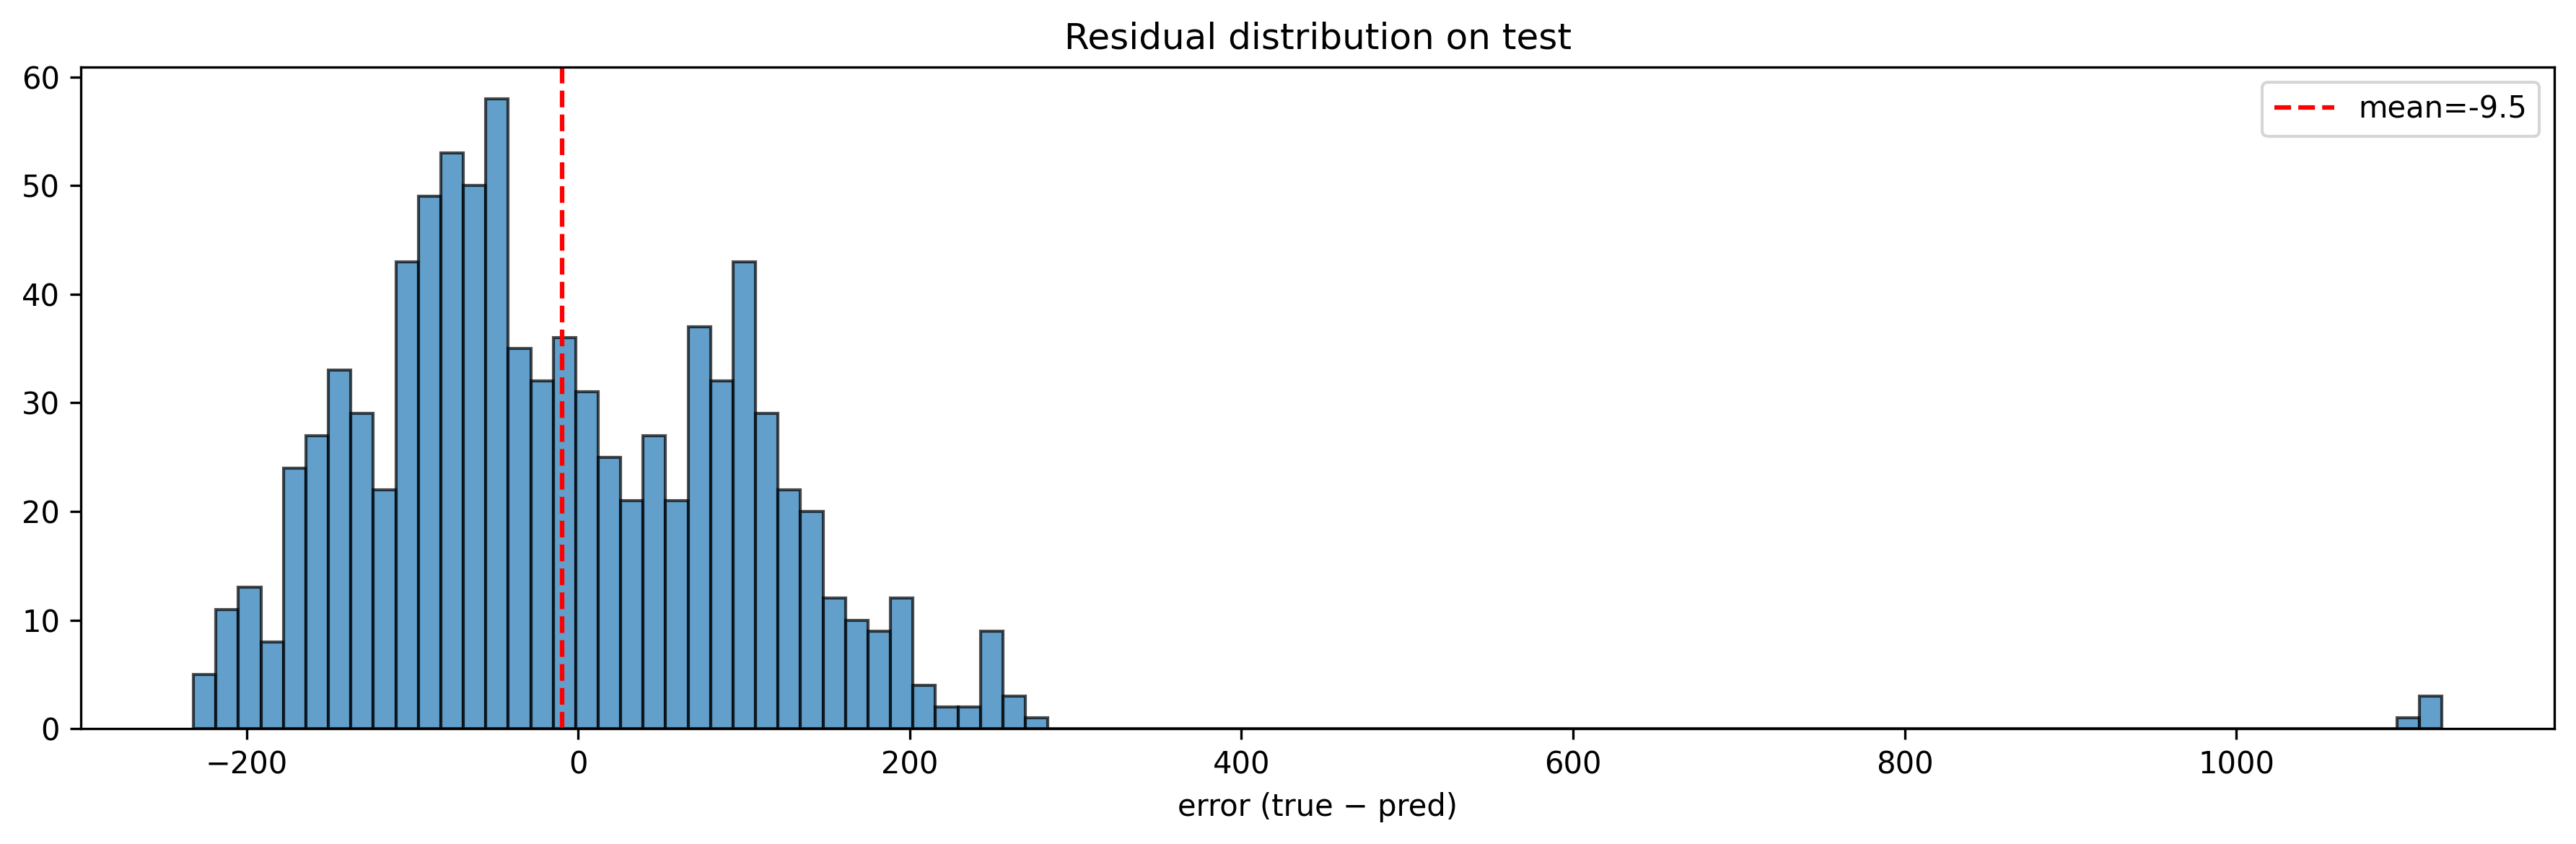

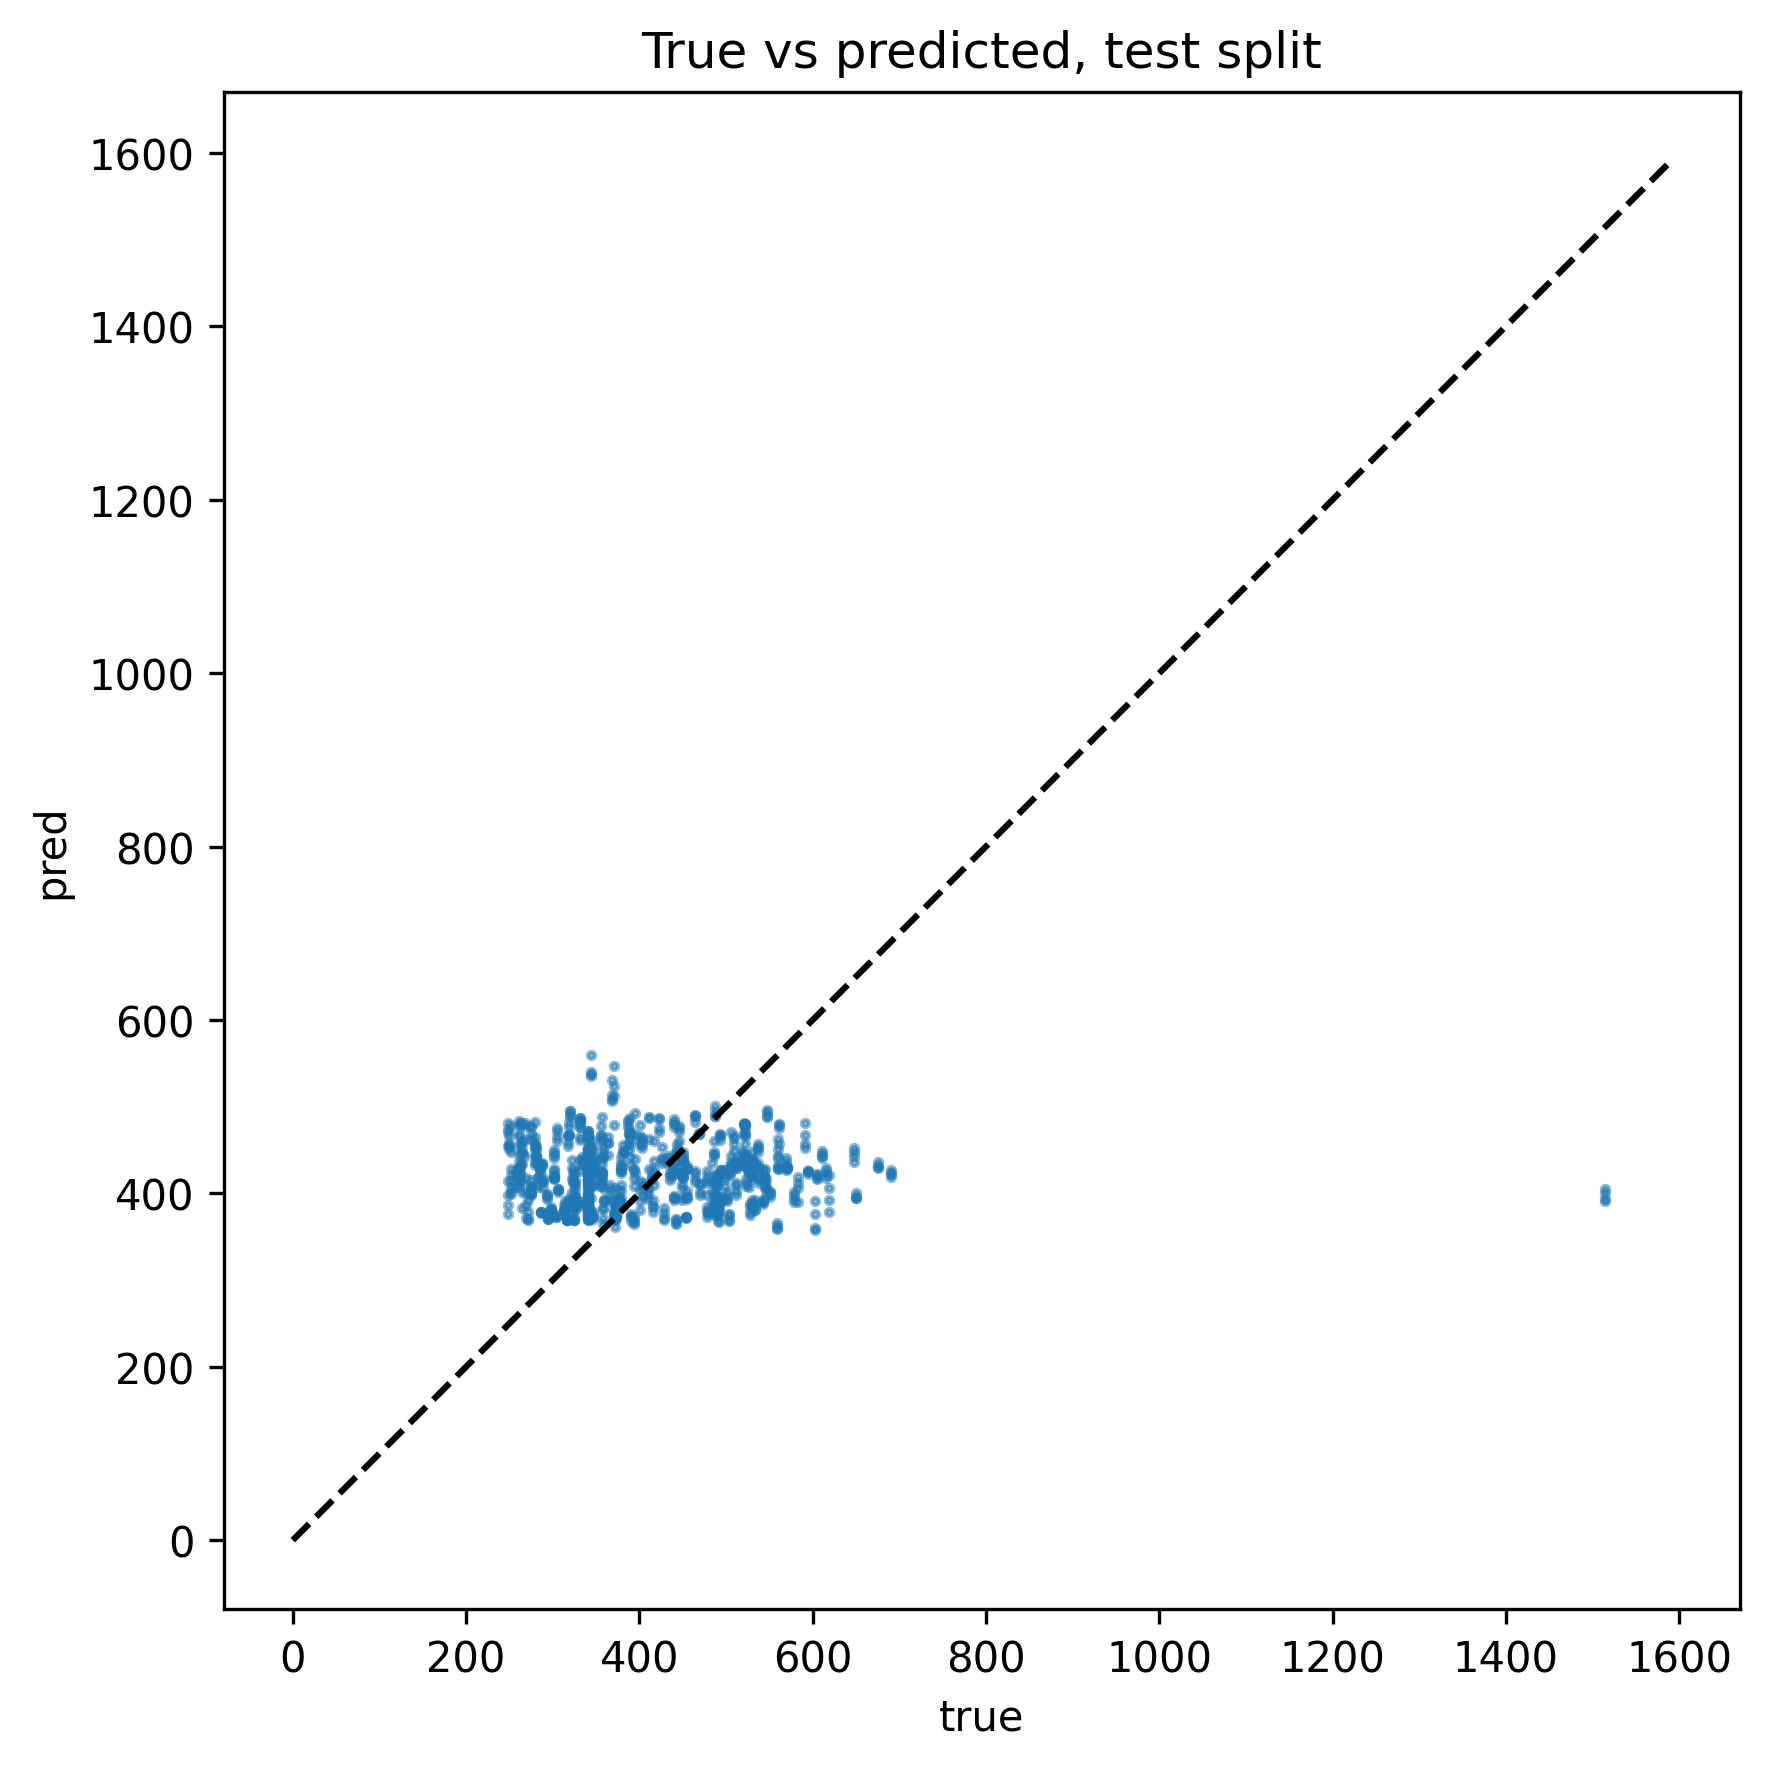

In [12]:
resid = y_true - y_pred


# ---------------------------------------------------
# 2.2  сводные метрики
# ---------------------------------------------------
metrics = global_metrics(y_true, y_pred)
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
logging.info("\n*** Hold-out metrics ***")
logging.info(metrics_df)

# ---------------------------------------------------
# 2.3  метрики по суткам
# ---------------------------------------------------
daily_mae_result = daily_mae(y_true, y_pred)
logging.info("\nMAE by day:")
logging.info(daily_mae_result.tail())

# ---------------------------------------------------
# 2.4  распределение ошибок
# ---------------------------------------------------
plt.figure(figsize=(12,4))
plt.hist(resid, bins=100, alpha=.7, edgecolor='black')
plt.axvline(resid.mean(), color='r', linestyle='--', label=f"mean={resid.mean():.1f}")
plt.title("Residual distribution on test")
plt.xlabel("error (true − pred)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 2.5  true vs pred scatter
# ---------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.5)
lim = [0, max(y_true.max(), y_pred.max())*1.05]
plt.plot(lim, lim, 'k--')
plt.xlabel("true"); plt.ylabel("pred")
plt.title("True vs predicted, test split")
plt.tight_layout(); plt.show()


In [13]:
# model = final_model
feat_names = model.model.feature_names_        # ← то, что CatBoost запомнил
importances = model.model.get_feature_importance(type='FeatureImportance')

# в один датафрейм
imp_df = (pd.DataFrame({"feature": feat_names,
                        "importance": importances})
            .sort_values(by="importance", ascending=False)
            .reset_index(drop=True))

logging.info(imp_df.head(20))
# ---------------------------------------------------
#  топ-20 на графике
# ---------------------------------------------------
plt.figure(figsize=(10,6))
plt.barh(imp_df.feature[::-1],
         imp_df.importance[::-1])
# plt.barh(imp_df.feature.head(20)[::-1],
#          imp_df.importance.head(20)[::-1])
plt.title("Top-20 feature importances (CatBoost)")
plt.tight_layout(); plt.show()


NameError: name 'model' is not defined